## MVP ANA — Semantic Search over STJ Súmulas

### Project Overview

This notebook implements an 8-step NLP pipeline that transforms the STJ Súmulas PDF into a semantic search index.

**Pipeline Summary:**
1. Read raw text from the STJ Súmulas PDF (with OCR fallback)
2. Normalize encoding artifacts (mojibake, smart quotes)
3. Remove repeated boilerplate headers using TF-IDF similarity
4. Segment the document into one block per Súmula
5. Normalize legal citations to typed placeholder tokens
6. Label each Súmula segment with its legal area, sub-area, and Súmula number
7. Generate BERTimbau embeddings (mean-pooled, sliding window)
8. Build a FAISS semantic search index and visualize similarity distributions

**Domain:** Brazilian Superior Court of Justice (STJ) — Súmulas are binding legal summaries grouped by legal area.

**Reference:** [STJ Súmulas PDF](https://www.stj.jus.br/docs_internet/VerbetesSTJ_asc.pdf)

### Import Libraries

Install required packages and import all pipeline modules. Modules are reloaded to pick up source changes without restarting the kernel.

In [1]:
%pip install pdfplumber pytesseract Pillow ftfy scikit-learn transformers torch numpy matplotlib faiss-cpu

import warnings
import logging
import importlib
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

scripts_path = Path("./pipeline/scripts")
if str(scripts_path.resolve()) not in sys.path:
    sys.path.insert(0, str(scripts_path.resolve()))

import pipeline_step, pipeline_manager
import step_0_pdf_reader, step_1_encoding_normalizer, step_2_boilerplate_remover
import step_3_sentence_segmenter, step_4_citation_normalizer
import step_5_labeler, step_6_embedding_generator
import step_7_search_index, step_8_similarity_visualizer

for mod in [pipeline_step, pipeline_manager,
            step_0_pdf_reader, step_1_encoding_normalizer, step_2_boilerplate_remover,
            step_3_sentence_segmenter, step_4_citation_normalizer,
            step_5_labeler, step_6_embedding_generator,
            step_7_search_index, step_8_similarity_visualizer]:
    importlib.reload(mod)

from pipeline_step import PipelineStep
from pipeline_manager import PipelineManager
from step_0_pdf_reader import PdfReader, PdfReaderInput
from step_1_encoding_normalizer import EncodingNormalizer
from step_2_boilerplate_remover import BoilerplateRemover
from step_3_sentence_segmenter import SentenceSegmenter
from step_4_citation_normalizer import CitationNormalizer
from step_5_labeler import SumulaLabeler
from step_6_embedding_generator import EmbeddingGenerator
from step_7_search_index import SearchIndexBuilder
from step_8_similarity_visualizer import SimilarityVisualizer

Note: you may need to restart the kernel to use updated packages.


### Pipeline Configuration

All tunable parameters are declared here as a single source of truth. Change values in this cell before re-running the pipeline — downstream cells reference these variables directly.

In [2]:
random_seed = 42  # PARAMETER: single source of randomness

pdf_path = Path("./datasets/Súmulas - STJ.pdf")  # PARAMETER: input PDF
ocr_fallback = True  # PARAMETER: OCR fallback for scanned pages
min_page_text = 50  # PARAMETER: min chars per page before OCR

tfidf_threshold = 0.92  # PARAMETER: boilerplate detection threshold
min_sentence_tokens = 5  # PARAMETER: min tokens per segment

embedding_batch_size = 16  # PARAMETER: sentences per inference batch
max_tokens = 512  # PARAMETER: BERT context window
overlap_tokens = 64  # PARAMETER: sliding window overlap
embedding_model_name = "neuralmind/bert-large-portuguese-cased"  # PARAMETER: embedding model

search_query = "banco cobrou taxa de juros abusiva no contrato"  # PARAMETER: search query
search_top_k = 1000  # PARAMETER: number of results for visualization

checkpoint_dir = Path("./pipeline/checkpoints")
figures_dir = Path("./pipeline/figures")

### Build Pipeline

Instantiate all pipeline steps in execution order and register them with `PipelineManager`. The manager uses pickle-based checkpoints so that expensive steps (especially step 6 — BERTimbau inference) are loaded from disk on subsequent runs instead of re-executing.

In [3]:
steps = [
    PdfReader(min_text_length=min_page_text),
    EncodingNormalizer(),
    BoilerplateRemover(tfidf_threshold=tfidf_threshold),
    SentenceSegmenter(min_tokens=min_sentence_tokens),
    CitationNormalizer(),
    SumulaLabeler(),
    EmbeddingGenerator(
        max_tokens=max_tokens,
        overlap_tokens=overlap_tokens,
        batch_size=embedding_batch_size,
        model_name=embedding_model_name,
    ),
    SearchIndexBuilder(query=search_query, top_k=search_top_k),
    SimilarityVisualizer(output_dir=figures_dir),
]
manager = PipelineManager(checkpoint_dir=checkpoint_dir, steps=steps)
status = manager.checkpoint_status()
print("Checkpoint status:")
for step_num, exists in status.items():
    print(f"  Step {step_num:2d}: {'cached' if exists else 'pending'}")

Checkpoint status:
  Step  0: cached
  Step  1: cached
  Step  2: cached
  Step  3: cached
  Step  4: cached
  Step  5: cached
  Step  6: cached
  Step  7: cached
  Step  8: pending


### Step 0. Read Text from PDF

Extracts raw text from the STJ Súmulas PDF using `pdfplumber`. Pages with fewer than `min_page_text` characters are re-processed with Tesseract OCR to recover scanned content. The raw text is stored as a single string for downstream normalization.

In [4]:
pdf_input = PdfReaderInput(pdf_path=pdf_path, ocr_fallback=ocr_fallback, min_text_length=min_page_text)
step0_output = manager.run_step(0, pdf_input)
print(f"Pages processed: {step0_output.page_count}")
print(f"OCR pages: {len(step0_output.ocr_pages)}")
print(f"Total characters: {len(step0_output.raw_text):,}")

Pages processed: 2642
OCR pages: 0
Total characters: 5,391,932


### Step 1. Encoding Normalization

Repairs mojibake and encoding artifacts introduced by the PDF text layer (e.g., curly quotes, em-dashes, Latin-1 sequences misread as UTF-8). `ftfy` is used to fix common encoding issues deterministically.

In [5]:
step1_output = manager.run_step(1, step0_output)
print(f"Replacements applied: {len(step1_output.replacements)}")

Replacements applied: 0


### Step 2. Boilerplate Removal

Detects and replaces repeated page headers and footers with a `BOILERPLATE_TOKEN` sentinel. TF-IDF cosine similarity between adjacent text blocks identifies repetitions above `tfidf_threshold`. This preserves the delimiter structure needed for segmentation in the next step.

In [6]:
step2_output = manager.run_step(2, step1_output)
print(f"Segments replaced: {step2_output.removed_count}")

Segments replaced: 16270


### Step 3. Súmula Segmentation

Splits the filtered text into individual Súmula blocks using `BOILERPLATE_TOKEN` boundaries as natural delimiters. Each page header position in the original PDF separates consecutive Súmulas, so the token positions become reliable split points. Falls back to double-newline paragraph splitting when fewer than two boilerplate boundaries are found.

In [7]:
step3_output = manager.run_step(3, step2_output)
print(f"Súmula segments extracted: {step3_output.sentence_count}")
print(f"\nSample segment (first 300 chars):\n{step3_output.sentences[0][:300]!r}")

Súmula segments extracted: 288

Sample segment (first 300 chars):
'SUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO 30\nSúmula 407 30\nSúmula 412 33\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA 35\nSúmula 624 35\nSúmula 647 38\nDIREITO ADMINISTRATIVO - ATIVIDADE FARMACÊUTICA 43\nSúmula 120 43\nSúmula 275 46\nSúmula 413 50\nSúmula 561 53\nDIREITO ADMINISTRATIVO - BEM PÚBLICO 60\nSú'


### Step 4. Citation Normalization

Replaces legal citation strings (article references, process numbers, case references, Súmula references) with typed placeholder tokens such as `<ART_REF>` and `<CASE_REF>`. This prevents downstream embeddings from treating idiosyncratic citation strings as meaningful semantic features while preserving the original text in `citation_metadata` for traceability.

In [8]:
step4_output = manager.run_step(4, step3_output)
total_citations = sum(len(m) for m in step4_output.citation_metadata)
print(f"Total citations normalized: {total_citations}")

Total citations normalized: 525


### Step 5. Súmula Labeling

Each Súmula segment is labeled using the document header lines (area + sub-area) that appear before the `Súmula N` declaration line. The STJ PDF groups Súmulas under bold legal area headings (e.g., `BANCÁRIO`) and sub-area headings (e.g., `Contrato Bancário`). Labels follow the pattern `Area_Sub_area_N` with accent-stripped title-case sanitization.

In [9]:
step5_output = manager.run_step(5, step4_output)
print(f"Labeled súmulas: {len(step5_output.labeled_sentences)}")
print(f"\nSample labels (first 10):")
for ls in step5_output.labeled_sentences[:10]:
    print(f"  {ls.label}")

Labeled súmulas: 288

Sample labels (first 10):
  Sumula_412_33_Desconhecido_407
  Administrativo_Agua_E_Esgoto_412
  Administrativo_Anistia_Politica_647
  Administrativo_Atividade_Farmaceutica_275
  Administrativo_Atividade_Farmaceutica_413
  Administrativo_Atividade_Farmaceutica_561
  Administrativo_Bem_Publico_619
  Administrativo_Codigo_De_Transito_Brasileiro_312
  Administrativo_Codigo_De_Transito_Brasileiro_434
  Administrativo_Codigo_De_Transito_Brasileiro_510


### Step 6. Embedding Generator

[STEP CAN BE SKIPPED - re-runs use checkpoint]

Encodes each labeled Súmula segment into a dense vector using the BERTimbau model (`neuralmind/bert-large-portuguese-cased`). Mean pooling over all non-padding token hidden states produces a single vector per segment. Segments exceeding 512 tokens are handled via a sliding window with `overlap_tokens` overlap; window embeddings are averaged. Label metadata is propagated into `EmbeddedSentence` for downstream use.

In [10]:
step6_output = manager.run_step(6, step5_output)
print(f"Model: {step6_output.model_name}")
print(f"Embedding dim: {step6_output.embedding_dim}")
print(f"Embedded sentences: {len(step6_output.embedded_sentences)}")

Model: neuralmind/bert-large-portuguese-cased
Embedding dim: 1024
Embedded sentences: 288


### Step 7. Semantic Search Index

FAISS inner-product index over L2-normalized BERTimbau embeddings. At query time the Portuguese input is encoded with the same model and the top-K most similar Súmulas are returned with their label and similarity score. Cosine similarity is equivalent to inner product on L2-normalized vectors, so `faiss.IndexFlatIP` is the correct choice. The step persists its output as a checkpoint so the FAISS build and BERTimbau query encoding are skipped on re-runs.

In [11]:
step7_output = manager.run_step(7, step6_output)

print(f"Query: {step7_output.query!r}")
print(f"Results returned: {len(step7_output.results)}")
print(f"Accumulated similarity: {step7_output.accumulated_similarity:.4f}")
print()
for r in step7_output.results[:10]:
    print(f"  [{r.rank:2d}] sim={r.similarity:.4f}  label={r.label}")
    print(f"       {r.text[:120]!r}")
    print()

Query: 'banco cobrou taxa de juros abusiva no contrato'
Results returned: 288
Accumulated similarity: 174.2831

  [ 1] sim=0.7324  label=Bancario_Contrato_Bancario_296
       'SÚMULA 296\nDIREITO BANCÁRIO - CONTRATO BANCÁRIO\nEnunciado: Órgão Julgador:\nOs juros remuneratórios, não cumuláveis com a'

  [ 2] sim=0.7016  label=Bancario_Contrato_Bancario_382
       'SÚMULA 382\nDIREITO BANCÁRIO - CONTRATO BANCÁRIO\nEnunciado: Órgão Julgador:\nA estipulação de juros remuneratórios superio'

  [ 3] sim=0.6950  label=Bancario_Contrato_Bancario_294
       'SÚMULA 294\nDIREITO BANCÁRIO - CONTRATO BANCÁRIO\nEnunciado: Órgão Julgador:\nNão é potestativa a cláusula contratual que p'

  [ 4] sim=0.6883  label=Bancario_Contrato_Com_Garantia_De_Alienacao_566
       'SÚMULA 566\nDIREITO BANCÁRIO - CONTRATO COM GARANTIA DE ALIENAÇÃO\nFIDUCIÁRIA\nEnunciado: Órgão Julgador:\nNos contratos ban'

  [ 5] sim=0.6860  label=Bancario_Contrato_Com_Garantia_De_Alienacao_284
       'SÚMULA 284\nDIREITO BANCÁRIO 

### Step 8. Similarity Intensity Visualization

A cosine similarity histogram is produced for the configured query:
- **Histogram** — distribution of cosine similarity scores across all retrieved Súmulas, using 40 bins. The X axis shows cosine similarity and the Y axis shows count.

The figure is saved to `figures_dir` as `similarity_histogram.png`.

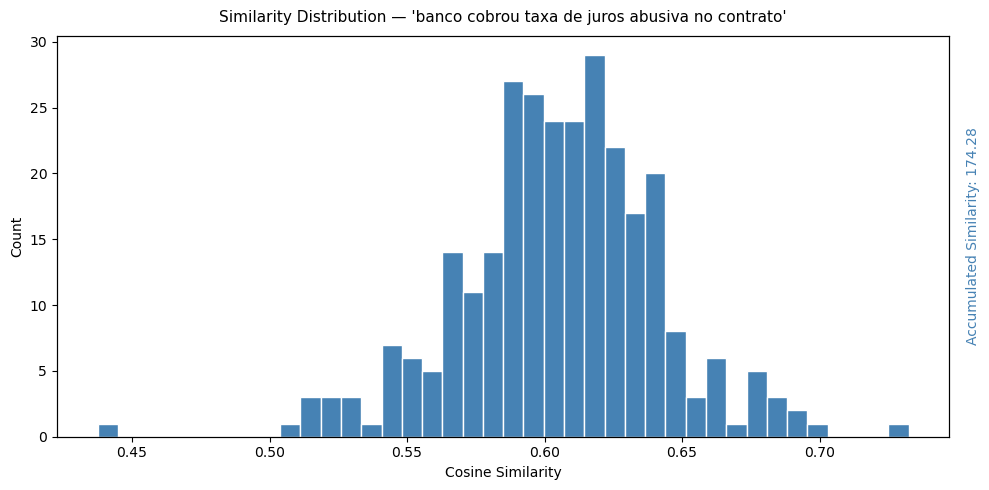

Figures saved: ['pipeline/figures/similarity_histogram.png']


In [12]:
step8_output = manager.run_step(8, step7_output)

for fig in step8_output.figures:
    plt.show()
print(f"Figures saved: {[str(p) for p in step8_output.saved_paths]}")

### Considerations

- **Label extraction** depends on consistent document header formatting in the STJ PDF. Non-standard sections may fall back to `Desconhecido_Desconhecido_N`.
- **Semantic similarity** is cosine distance in BERTimbau embedding space. Súmulas that are lexically distant but thematically close will rank highly, which is the intended behavior for cross-area legal reasoning.
- **Query language** must be Portuguese. English or mixed-language queries will not align with the embedding space trained on Portuguese legal text.
- **Checkpoint reuse** means that changing `embedding_model_name` or earlier step parameters requires clearing the affected checkpoint files before re-running.
- **FAISS index** is rebuilt in memory on each session from the step 6 checkpoint; it is not persisted separately.

### Conclusions

The 8-step pipeline transforms the STJ Súmulas PDF into an interactive semantic search tool without any clustering dependency:

| Step | Component | Role |
|------|-----------|------|
| 0 | PdfReader | Extract raw text with OCR fallback |
| 1 | EncodingNormalizer | Repair encoding artifacts |
| 2 | BoilerplateRemover | Mark repeated headers as delimiters |
| 3 | SentenceSegmenter | Split into per-Súmula blocks |
| 4 | CitationNormalizer | Replace citations with typed tokens |
| 5 | SumulaLabeler | Annotate area + sub-area + number |
| 6 | EmbeddingGenerator | BERTimbau mean-pooled vectors |
| 7 | SearchIndexBuilder | FAISS cosine similarity search with checkpoint |
| 8 | SimilarityVisualizer | Cosine similarity histogram |

The label-aware search index enables targeted retrieval of Súmulas by legal area while the visualizer reveals where semantic intensity concentrates across the complete 502-Súmula corpus for any Portuguese legal query.